# Layer By Layer and align a trajectory along a selected axes.

In [1]:
from snow.io.xyz import read_xyz
from snow.descriptors.distributions import cut_layers

In [2]:
path='tutorial_structures/Cu247_Dh.xyz'

cu_lattice = 3.615 #AA
bin_height = 1.0*cu_lattice

el, coords=read_xyz(path)
print(f'{len(el)} atoms read')

layer_numbers, atoms_per_layer = cut_layers(el, coords, bin_height, cutting_ax='z')
#add later examples for multi-specie configs

247 atoms read


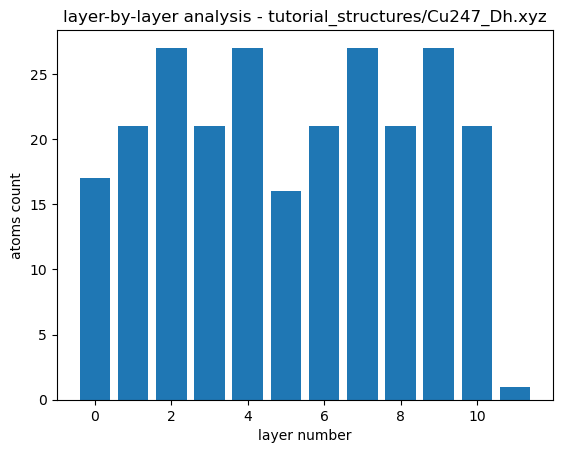

In [3]:
#an optional plot
import matplotlib.pyplot as plt

plt.figure()
plt.bar(layer_numbers, atoms_per_layer)
plt.xlabel('layer number')
plt.ylabel('atoms count')
plt.title(f'layer-by-layer analysis - {path}')
plt.show()

## Rotations

In [8]:
from snow.io.xyz import write_xyz, read_xyz
from snow.transform.rototranslation import align_axis_to_z, rotate_around_ax, ax_from_two_points

from snow.descriptors.shape_descriptors import center_of_mass, geometric_com as gcom

import numpy as np

path = 'tutorial_structures/Cu247_Dh.xyz'
cu_lattice = 3.615 #AA
el, coords = read_xyz(path)

el = np.asarray(el, dtype=str)

coords_cu = coords[el == 'Cu'] #use numpy fancy indexing (el == 'Cu' creates a mask if el is a npndarray)
coords_pt = coords[el == 'Pt']

center_of_mass_cu = gcom(coords_cu)
center_of_mass_pt = gcom(coords_pt)

connecting_ax = ax_from_two_points(center_of_mass_cu, center_of_mass_pt)

c1 = align_axis_to_z(coords, [1.,0.,0.])
cc = rotate_around_ax(coords, (0,0,1), 30)

write_xyz(filename = 'tutorial_structures/Cu247_Dh_cc.xyz', elements = el, coords = cc)
write_xyz(filename = 'tutorial_structures/Cu247_Dh_c1.xyz', elements = el, coords = c1)

In [9]:


coords[:][3]

#write_xyz(filename = '/Users/szinzani/Documents/Codici/pySNOW/tutorial/tutorial_structures/Cu247_Dh_cc.xyz', elements = el, coords = cc)

array([  0.       ,   0.       , -12.7632774])

In [11]:




#########


path='tutorial_structures/Cu247_Dh.xyz'

cu_lattice=3.615 #AA
el, coords=read_xyz(path)
print(len(el))

new_coords=align_axis_to_z(coords, (0,1,1))
write_xyz(filename = 'tutorial_structures/Cu247_Dh_rotated_1.xyz', elements = el, coords = new_coords)






print(new_coords)

new_coords_2=align_axis_to_z(new_coords, (0,0,1))
write_xyz(filename = 'tutorial_Structures/Cu247_Dh_rotated_2.xyz', elements = el, coords = new_coords_2)



247
[[  0.          14.44       -14.44      ]
 [  0.          12.635      -12.635     ]
 [  0.          10.83       -10.83      ]
 [  0.           9.025       -9.025     ]
 [  0.           7.22        -7.22      ]
 [  0.           5.415       -5.415     ]
 [  0.           3.61        -3.61      ]
 [  0.           1.805       -1.805     ]
 [  0.           0.           0.        ]
 [  0.          -1.805        1.805     ]
 [  0.          -3.61         3.61      ]
 [  0.          -5.415        5.415     ]
 [  0.          -7.22         7.22      ]
 [  0.          -9.025        9.025     ]
 [  0.         -10.83        10.83      ]
 [  0.         -12.635       12.635     ]
 [  0.         -14.44        14.44      ]
 [  2.10246687  14.02054791 -13.05445209]
 [  2.10246687  12.21554791 -11.24945209]
 [  2.10246687  10.41054791  -9.44445209]
 [  2.10246687   8.60554791  -7.63945209]
 [  2.10246687   6.80054791  -5.83445209]
 [  2.10246687   4.99554791  -4.02945209]
 [  2.10246687   3.19054791  -

In [12]:
print(new_coords_2)

[[  0.          14.44       -14.44      ]
 [  0.          12.635      -12.635     ]
 [  0.          10.83       -10.83      ]
 [  0.           9.025       -9.025     ]
 [  0.           7.22        -7.22      ]
 [  0.           5.415       -5.415     ]
 [  0.           3.61        -3.61      ]
 [  0.           1.805       -1.805     ]
 [  0.           0.           0.        ]
 [  0.          -1.805        1.805     ]
 [  0.          -3.61         3.61      ]
 [  0.          -5.415        5.415     ]
 [  0.          -7.22         7.22      ]
 [  0.          -9.025        9.025     ]
 [  0.         -10.83        10.83      ]
 [  0.         -12.635       12.635     ]
 [  0.         -14.44        14.44      ]
 [  2.10246687  14.02054791 -13.05445209]
 [  2.10246687  12.21554791 -11.24945209]
 [  2.10246687  10.41054791  -9.44445209]
 [  2.10246687   8.60554791  -7.63945209]
 [  2.10246687   6.80054791  -5.83445209]
 [  2.10246687   4.99554791  -4.02945209]
 [  2.10246687   3.19054791  -2.22